In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

plt.style.use("ggplot")


In [2]:
df = pd.read_csv(
    "../data/processed/reddit_posts_cleaned.csv"
)

df.head()

,keyword,title,subreddit,timestamp,post_url,scrape_date,batch_number,source,clean_title,location,skill,role
0,developersindia hiring,How's Infosys for starters 😳,r/IndiaTech,2026-03-10T07:42:32+00:00,https://old.reddit.com/r/IndiaTech/comments/1r...,NaN,NaN,NaN,hows infosys for starters,Unknown,Unknown,Software Engineer
1,developersindia hiring,Who's hiring? - Monthly Megathread - June 2026,r/developersIndia,2026-06-01T04:32:05+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread june 2026,Unknown,Unknown,Software Engineer
2,developersindia hiring,Who's hiring? - Monthly Megathread - February ...,r/developersIndia,2026-02-01T04:32:29+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread february 2026,Unknown,Unknown,Software Engineer
3,developersindia hiring,Who's looking for work? - Monthly Megathread -...,r/developersIndia,2026-06-01T04:30:14+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos looking for work monthly megathread june ...,Unknown,Unknown,Software Engineer
4,developersindia hiring,Who's hiring? - Monthly Megathread - May 2026,r/developersIndia,2026-05-01T04:32:13+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread may 2026,Unknown,Unknown,Software Engineer


In [3]:
vectorizer = TfidfVectorizer(

    stop_words="english",

    max_features=1000

)

tfidf = vectorizer.fit_transform(

    df["clean_title"]

)

In [4]:
scores = tfidf.sum(axis=0).A1

words = vectorizer.get_feature_names_out()

importance = pd.DataFrame({

    "word": words,

    "score": scores

})

importance = importance.sort_values(

    by="score",

    ascending=False

)

importance.head(20)

,word,score
427,hiring,96.156536
457,india,91.043799
484,job,71.513886
300,engineer,66.020872
739,remote,60.967302
267,developer,57.983034
826,software,54.739764
246,data,45.539790
77,ai,40.865713
543,looking,38.232674


# Graph 1 — Top 20 TF-IDF Words


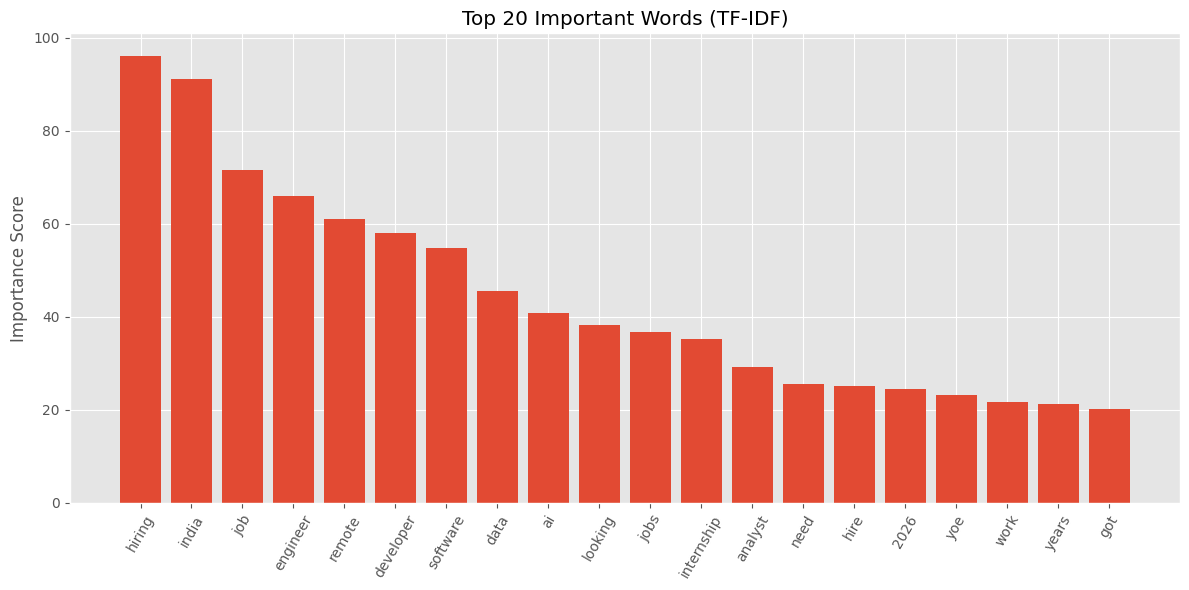

In [5]:
top20 = importance.head(20)

plt.figure(figsize=(12,6))

plt.bar(

    top20["word"],

    top20["score"]

)

plt.xticks(rotation=60)

plt.title("Top 20 Important Words (TF-IDF)")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.show()

# Graph 2 — Horizontal Bar Chart

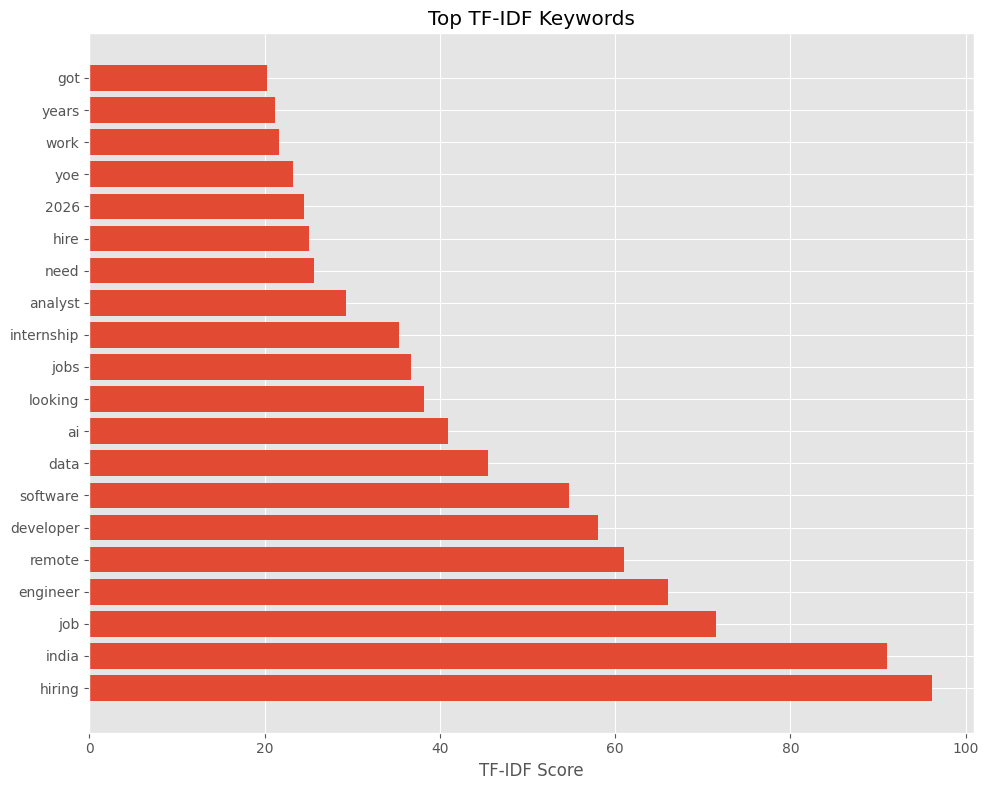

In [6]:
plt.figure(figsize=(10,8))

plt.barh(

    top20["word"],

    top20["score"]

)

plt.title("Top TF-IDF Keywords")

plt.xlabel("TF-IDF Score")

plt.tight_layout()

plt.show()

# Graph 3 — Histogram of TF-IDF Scores

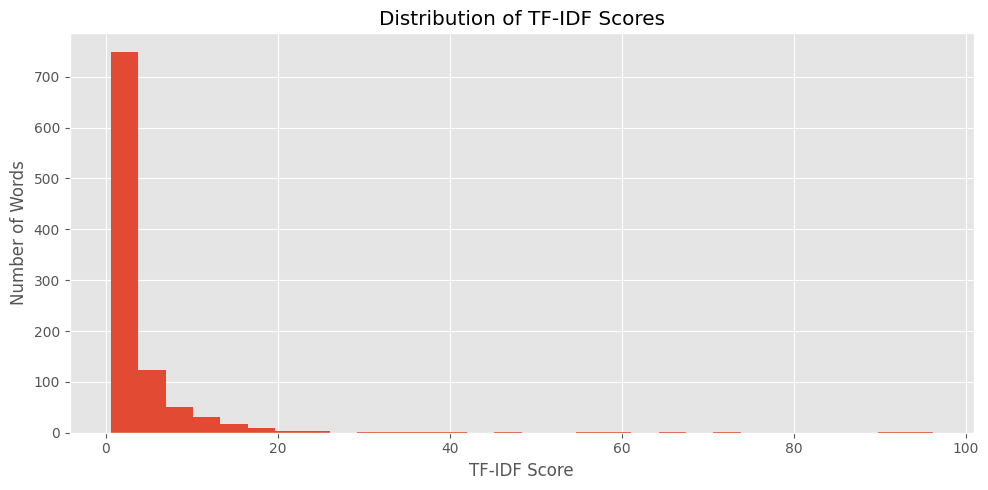

In [7]:
plt.figure(figsize=(10,5))

plt.hist(

    importance["score"],

    bins=30

)

plt.title("Distribution of TF-IDF Scores")

plt.xlabel("TF-IDF Score")

plt.ylabel("Number of Words")

plt.tight_layout()

plt.show()